In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import time
import gc
import math

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.functional as VF
from torch.autograd.graph import saved_tensors_hooks

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from torch_utils import gpu_utils
from torch_utils import cuda_utils
from torch_utils import training_utils

In [4]:
device = 'cuda'
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


## Functions

In [5]:
def calculate_training_memory(model, dataset, criterion, batch_size=4, device="cuda"):
    model.to(device)
    model.zero_grad()
    model.train()

    total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    dataLoader = DataLoader(
        dataset=dataset,
        batch_size=batch_size)

    input, target = next(iter(dataLoader))
    input, target = input.to(device), target.to(device)

    seen_ptrs = set([p.data_ptr() for p in model.parameters()]) # To avoid storing model parameters
    saved = []

    def pack_hook(t):
        # Runs during forward when autograd saves a tensor
        tensor_dict = {
            "shape": t.shape,
            "dtype": t.dtype,
            "device": t.device,
            "requires_grad": t.requires_grad,
            "numel": t.numel(),
            "element_size": t.element_size(),
            "memory" : t.numel() * t.element_size(),
            "data_ptr": t.data_ptr()
        }
        if not t.data_ptr() in seen_ptrs:
            saved.append(tensor_dict)
            seen_ptrs.add(t.data_ptr())
        return t

    def unpack_hook(t):
        # Runs during backward when autograd unpacks it
        return t

    with saved_tensors_hooks(pack_hook, unpack_hook):
        logits = model(input)
        loss = criterion(logits, target)
        loss.backward()

    activation_memory = sum(s["memory"] for s in saved)
    result = {
        "number_of_params": total_params,
        "memory_activations_per_example": activation_memory / batch_size,
        "memory_params": total_params * 4,
        "memory_grad": total_params * 4,
        "memory_adam": total_params * 8,
        "memory_total": activation_memory + total_params * 16,
        "unit": "B"
    }
    return result

## Dataset

In [46]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./DATA",
    train=True,
    download=True,
    transform=transform)

valid_dataset = datasets.MNIST(
    root="./DATA",
    train=False,
    download=True,
    transform=transforms.ToTensor())    

## Model class

In [53]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 1024)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)        
        return x

## Basic model objects

In [68]:
model = SimpleNN().to(device)
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=0.001,
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

## Calculate max batch size

In [55]:
max_batch_size = training_utils.find_max_train_batch(
    model = model,
    dataset = train_dataset,
    optimizer = optimizer,
    criterion = criterion,
    device = device,
    verbose = True)

Current batch = 30000 Result: True
Current batch = 45000 Result: True
Current batch = 52500 Result: True
Current batch = 56250 Result: True
Current batch = 58125 Result: True
Current batch = 59062 Result: True
Current batch = 59531 Result: True
Current batch = 59765 Result: True
Current batch = 59882 Result: True
Current batch = 59941 Result: True
Current batch = 59970 Result: True
Current batch = 59985 Result: True
Current batch = 59992 Result: True
Current batch = 59996 Result: True
Current batch = 59998 Result: True
Current batch = 59999 Result: True


## Calculate max throughput

In [56]:
batch_size_to_test = [1, 16, 64, 128, 256, 512, 1024, 1536, 2048, 3072, 4096, 6144, 8192]
throughput_results = {
    x:training_utils.calculate_throughput(
        model = model,
        dataset = train_dataset,
        optimizer = optimizer,
        criterion = criterion,
        batch_size = x,
        device = 'cuda', 
        max_time_s = 2) for x in batch_size_to_test
}

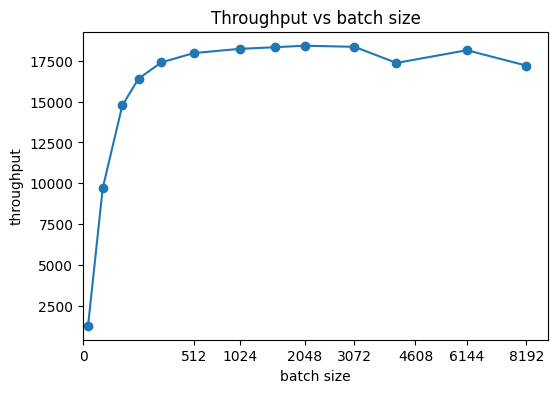

In [57]:
n_ticks = 8
x_ticks = sorted(list(set([math.floor(((x * (max(batch_size_to_test) ** 0.5) / n_ticks)**2)/512)*512 for x in range(n_ticks+1)])))
x = list(throughput_results.keys())
y = list(throughput_results.values())
plt.figure(figsize=(6,4))
plt.plot(x, y, marker='o', linestyle='-')
plt.xscale('function', functions=(lambda x: x**0.5, lambda x: x**2))
plt.xticks(x_ticks)
plt.xlabel('batch size')
plt.ylabel('throughput')
plt.title('Throughput vs batch size')
plt.show()

In [109]:
class callback_trainer:
    def on_epoch_end(self, trainer, epoch): pass
    def on_step_end(self, trainer, step): pass
        
class torch_trainer:
    def __init__(self, model, optimizer, criterion, device, callbacks=[]):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.callbacks = callbacks

        self._loss_epoch = []
        self._loss_step = []

        self.model.to(self.device)

    def _step(self, batch_x, batch_y):
        self.model.train()
        batch_x = batch_x.to(self.device)
        batch_y = batch_y.to(self.device)
        self.optimizer.zero_grad()
        output = self.model(batch_x)
        loss = self.criterion(output, batch_y)
        loss.backward()
        self.optimizer.step()
        self._loss_step.append(loss.item())

        for cb in self.callbacks:
            cb.on_step_end(trainer = self, step = len(self._loss_step)-1)
        return loss.item()

    def _eval_epoch(self, loader):
        self.model.eval()
        running_loss = 0.0
        n_obs = 0
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
            output = self.model(batch_x)
            loss = self.criterion(output, batch_y)
            running_loss += loss.item() * len(batch_x)
            n_obs += len(batch_x)
        running_loss = running_loss / n_obs
        return running_loss

    def fit(self, train_loader, n_epochs):
        self._loss_epoch = []
        self._loss_step = []
        
        for i in range(n_epochs):
            loss_epoch = 0
            num_obs_epoch = 0
            for batch_id, (batch_x, batch_y) in enumerate(train_loader):
                loss_step = self._step(batch_x, batch_y)
                loss_epoch +=  loss_step * len(batch_x)
                num_obs_epoch += len(batch_x)
            loss_epoch = loss_epoch / num_obs_epoch
            self._loss_epoch.append(loss_epoch)

            for cb in self.callbacks:
                cb.on_epoch_end(trainer = self, epoch = i)

class log_loss_callback(callback_trainer):
    def __init__(self, writer, loss_name):
        self.writer = writer
        self.loss_name = loss_name

    def on_epoch_end(self, trainer, epoch):
        self.writer.add_scalar(f"{self.loss_name}/epoch", trainer._loss_epoch[epoch], epoch)

    def on_step_end(self, trainer, step):
        self.writer.add_scalar(f"{self.loss_name}/step", trainer._loss_step[step], step)

class eval_valid_callback(callback_trainer):
    def __init__(self, writer, valid_loader, loss_name):
        self.writer = writer
        self.valid_loader = valid_loader
        self.loss_name = loss_name

    def on_epoch_end(self, trainer, epoch):
        valid_loss = trainer._eval_epoch(loader = self.valid_loader)
        self.writer.add_scalar(f"{self.loss_name}/epoch", valid_loss, epoch)

In [110]:
model = SimpleNN().to(device)
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=0.001,
    weight_decay=0.01
)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    #persistent_workers=True,
    drop_last=True)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
   # persistent_workers=True,
    drop_last=False)

In [111]:
exp_folder = f'runs/model_{int(time.time())}'
writer_train = SummaryWriter(f"{exp_folder}/train")
writer_valid = SummaryWriter(f"{exp_folder}/valid")

callbacks = [
    log_loss_callback(writer_train, "loss"),
    eval_valid_callback(writer_valid, valid_loader, "loss")
]

trainer = torch_trainer(
    model = model,
    optimizer = optimizer,
    criterion = criterion,
    device = device,
    callbacks = callbacks)
trainer.fit(
    train_loader = train_loader,
    n_epochs = 10)

In [17]:
n = 16
k = 256


exp_folder = f'runs/model_{int(time.time())}'
writer_train = SummaryWriter(f"{exp_folder}/train")
writer_valid = SummaryWriter(f"{exp_folder}/valid")
global_step = 0
beta1, beta2 = optimizer.param_groups[0]["betas"]
base_lr = optimizer.param_groups[0]["lr"]
eps = optimizer.param_groups[0]["eps"]
for epoch in range(1):
    running_loss = 0.0
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        running_loss += loss.item()

        # Log Params Batch
        total_param_norm = 0.0
        total_param_count = 0.0
        total_grad_norm = 0.0
        for name, param in model.named_parameters():
            if param.requires_grad:
                if "bias" in name:
                    short_name = name[:-5]
                    group_name = "Bias"
                else:
                    short_name = name[:-7]
                    group_name = "Weight"
                
                writer_train.add_scalar(f"{group_name}_param_norm_scaled/{short_name}", param.data.norm(2) / (param.data.numel() ** 0.5), global_step) 
                writer_train.add_scalar(f"{group_name}_gradient_norm/{short_name}", param.grad.data.norm(2), global_step) 

                total_param_norm += param.data.norm(2) ** 2
                total_param_count += param.data.numel()
                total_grad_norm += param.grad.data.norm(2) ** 2

                if global_step>0:
                    step = optimizer.state[param]['step'] 
                    m_t = optimizer.state[param]['exp_avg'] / (1 - beta1 ** step)
                    v_t = optimizer.state[param]['exp_avg_sq'] / (1 - beta2 ** step)
                    effective_update = base_lr * m_t / (v_t ** 0.5 + eps)
                    writer_train.add_scalar(f"{group_name}_update_ratio/{short_name}", effective_update.abs().mean() / param.detach().abs().mean(), global_step)
        
        writer_train.add_scalar(f"Total_norm/Param_scaled", (total_param_norm / total_param_count) ** 0.5, global_step) 
        writer_train.add_scalar(f"Total_norm/Gradient", total_grad_norm ** 0.5, global_step)
        writer_train.add_scalar("Loss/batch", loss.item(), global_step)
        
        global_step += 1
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() 

    # Log Params Epoch
    for name, param in model.named_parameters():
        if param.requires_grad:
            if "bias" in name:
                short_name = name[:-5]
                group_name = "Bias"
            else:
                short_name = name[:-7]
                group_name = "Weight"
        writer_train.add_histogram(f"{group_name}_param/{short_name}", param.data.cpu(), epoch)
        writer_train.add_histogram(f"{group_name}_gradient/{short_name}", param.grad.data.cpu(), epoch)
    loss_train_epoch = running_loss / len(train_loader)
    writer_train.add_scalar("Loss/epoch", loss_train_epoch, epoch)

    loss_valid_epoch = test_model(model = model, dataloader = test_loader, criterion = criterion)
    writer_valid.add_scalar("Loss/epoch", loss_valid_epoch, epoch)

    S = gradient_noise_scale(
        model = model,
        dataset = train_dataset,
        criterion = criterion,
        n = n,
        k = k)
    writer_train.add_scalar("Optimal_batch", int(S*k), epoch)

    writer_train.add_scalar("LR", scheduler.get_last_lr()[0], epoch)
    scheduler.step()
    
writer_train.close()
writer_valid.close()

NameError: name 'test_model' is not defined

In [ ]:
i = 1
data = model.fc1.weight.detach().cpu()[i, :].view(28, 28).cpu().numpy()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
img = plt.imshow(data, cmap='viridis', aspect='auto')
plt.colorbar(img, label="Weight value")
plt.show()

In [ ]:
(model.fc1.weight.detach().abs() < 0.01).to(torch.float32).mean()

In [ ]:
??optim.AdamW